# VampPriorVAE on Colored MNIST

In [ ]:
import sys

sys.path.append("../")

In [ ]:
from vae_project.imports import *
from vae_project.dataset import *
from vae_project.utils import *
from vae_project.train.hooks import *
from vae_project import get_dataset, VampPriorVAE, VampPriorTrainer, VampPriorHook

In [ ]:
train_ds, val_ds = get_dataset("../data"), get_dataset('../data', train=False)

batch_tfms = [ToBatchTransform(tv.transforms.Pad(2)), Colorize('label')]
collate_fn = CollateWithTransforms(batch_tfms)

In [ ]:
bs = 128
train_dl = DataLoader(train_ds, bs, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, bs*2, collate_fn=collate_fn)

In [ ]:
# K_train = 5  # importance samples during training
# K_eval = 50  # tighter bound for evaluation
seed = 42
latent_dim = 16
h_dim = 64
wd = 1e-4
channels = (3, 32, 64, 128)
epochs = 25
lr = 1e-3
beta_start = 0.0      # Start with no KL weight
beta_end = 0.6        # End with full KL weight

# VampPrior-specific hyperparameters
num_components = 100  # Standard number for VampPrior
use_pseudo_net = False  # False for direct parameters (faster), True for network generation

random_seed(seed)

dl_kwargs = dict(collate_fn=CollateWithTransforms(batch_tfms), num_workers=6, persistent_workers=True)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, **dl_kwargs)
val_dl = DataLoader(val_ds, batch_size=bs, **dl_kwargs)

# recon_dist = 'bce'

In [ ]:
# model = IWAE(channels, input_size=(32, 32), latent_dim=latent_dim, h_dim=h_dim, recon_dist=recon_dist)
model = VampPriorVAE(
    vampprior_or_channel_nums=channels,  # Channel configuration
    input_size=(32,32),             # Image dimensions (32, 32)
    latent_dim=latent_dim,             # Same latent dimension as IWAE
    num_components=num_components,    # VampPrior-specific: number of pseudo-inputs
    h_dim=h_dim,                       # Same hidden dimension as IWAE
    use_pseudo_net=use_pseudo_net,     # Whether to use network for pseudo-inputs
)

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
hooks = [
    MetricsHook(), 
    ProgressBarHook(),
    VampPriorHook(
        save_dir="./vampprior_results",  # Directory to save results
        save_every=5,                    # Save every 5 epochs
        device=default_device
    ),
    BetaSchedulerHook(start=beta_start, end=beta_end)
]

trainer_config = dict(
    model=model,
    train_dl=train_dl,
    valid_dl=val_dl,
    optim=optimizer,
    epochs=epochs,
    hooks=hooks,
)

trainer = VampPriorTrainer(**trainer_config)

In [ ]:
trainer.fit()

Epoch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/25 | Train Loss: 371.7526 | Val Loss: 205.3299


Epoch 2/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 24/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 159.7544 | Val Loss: 161.3087


Epoch 25/25 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 25/25 [Valid]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 160.2086 | Val Loss: 162.7436
✓ Saved checkpoint at epoch 25


In [ ]:
# t.save(model, "./vampprior_results/vp_vae_model.pt")

In [ ]:
trainer.model = model = t.load("./vampprior_results/vp_vae_model.pt", map_location=default_device, weights_only=False)

In [ ]:
trainer.get_hook(MetricsHook).plot_loss()

Text(0.5, 1.0, 'Inputs')

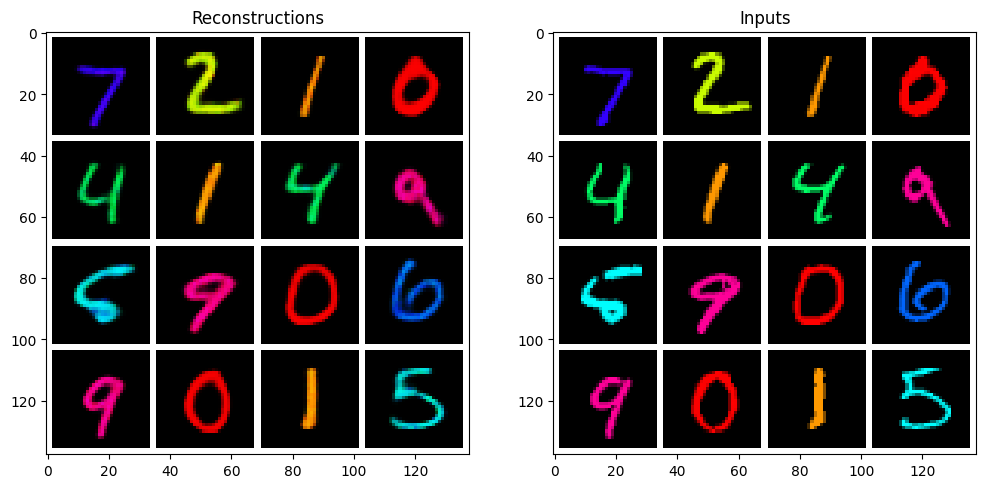

In [ ]:
xb, _ = next(iter(trainer.valid_dl))
x = xb[:16].to(default_device)
recon = trainer.predict(x)
axes = plt.subplots(ncols=2, figsize=(12,8))[1]
show_imgs(recon, axes[0])
axes[0].set_title('Reconstructions')
show_imgs(x, axes[1])
axes[1].set_title('Inputs')

### Samples

<Axes: >

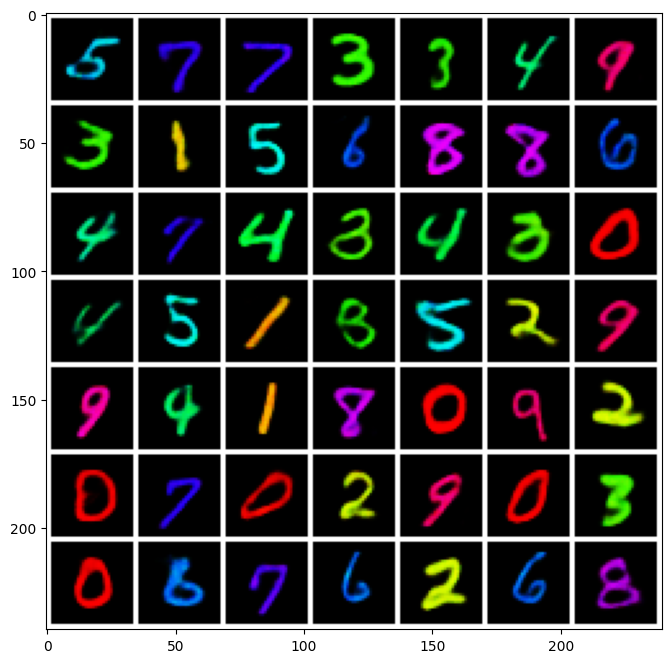

In [ ]:
ax = plt.subplots(figsize=(8,8))[1]
show_imgs(trainer.model.sample(49), ax=ax)